## PRCP-1012-GameWinnerPred

### TABLE OF CONTENTS
1. Understanding the Objective
2. Importing Required Libraries
3. Loading the Dataset and EDA
4. Scaling & Feature Engineering
5. Model Development
6. Conclusion and Insights

### 1. Objective
    Building a model to predict the win probability of the PUBG match, based on the given features.

### 2. Importing Necessaary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

pubg = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\AI GAME\Data\pubg.csv")
pubg

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.000,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.040,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.000,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.000,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.000,0,0,49.75,2,0,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,...,0,1292.0000,0,0.000,0,0,1019.00,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,...,0,0.0000,0,0.000,0,0,81.70,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,...,0,0.0000,0,2.184,0,0,788.70,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,4,180.40,1,1,2,11,...,2,0.0000,0,0.000,0,0,2748.00,8,0,0.8000


### Exploratory Data Analysis:
Duplicate Check: Verify the dataset for any duplicate entries to prevent redundant data. If duplicates are found, they should be removed to enhance the model’s performance.

Null Value Check: Inspect the dataset for missing values to avoid bias. If null values are present, they should be appropriately imputed or replaced based on the nature of the data.

Data Type Verification: Examine the data types of all features. If any non-numerical features exist, they must be encoded into numerical format before model training.

Statistical Summary: Perform an overall statistical analysis to understand metrics such as mean, median, standard deviation, and maximum values. This helps in effective feature engineering.

Visualization: Create visualizations to analyze features and gain better insights into their relationships.

In [2]:
pubg.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [3]:
pubg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

In [4]:
pubg.duplicated().sum()

np.int64(0)

In [5]:
pubg.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [6]:
pubg = pubg.dropna()
#Upon detecting a single null entry in the dataset, we opted to drop the record rather than impute the missing value.

In [7]:
pubg.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       0
dtype: int64

In [8]:
pubg.columns

Index(['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='object')

In [9]:
pubg.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,...,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06
mean,2.338150e-01,1.106908e+00,1.307172e+02,6.578757e-01,2.268196e-01,1.370148e+00,4.759936e+01,5.050062e+02,9.247835e-01,5.439553e-01,...,1.646590e-01,6.061158e+02,3.496092e-03,4.509323e+00,2.386841e-02,7.918209e-03,1.154218e+03,3.660488e+00,6.064603e+02,4.728216e-01
std,5.885731e-01,1.715794e+00,1.707806e+02,1.145743e+00,6.021553e-01,2.679982e+00,2.746293e+01,6.275049e+02,1.558445e+00,7.109721e-01,...,4.721671e-01,1.498344e+03,7.337297e-02,3.050220e+01,1.673935e-01,9.261158e-02,1.183497e+03,2.456543e+00,7.397005e+02,3.074050e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.551000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,0.000000e+00,0.000000e+00,8.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.856000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,0.000000e+00,2.000000e+00,1.860000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.172000e+03,1.000000e+00,1.000000e+00,...,0.000000e+00,1.910000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.976000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,2.200000e+01,3.300000e+01,6.616000e+03,5.300000e+01,6.400000e+01,8.000000e+01,1.010000e+02,2.170000e+03,7.200000e+01,2.000000e+01,...,3.900000e+01,4.071000e+04,1.800000e+01,3.823000e+03,1.200000e+01,5.000000e+00,2.578000e+04,2.360000e+02,2.013000e+03,1.000000e+00


#### Removed features that were unnecessary for the analysis.

In [10]:
pubg = pubg.drop(['Id', 'groupId', 'matchId'],axis=1)
pubg.columns

Index(['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
       'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill',
       'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints',
       'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
       'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
       'winPlacePerc'],
      dtype='object')

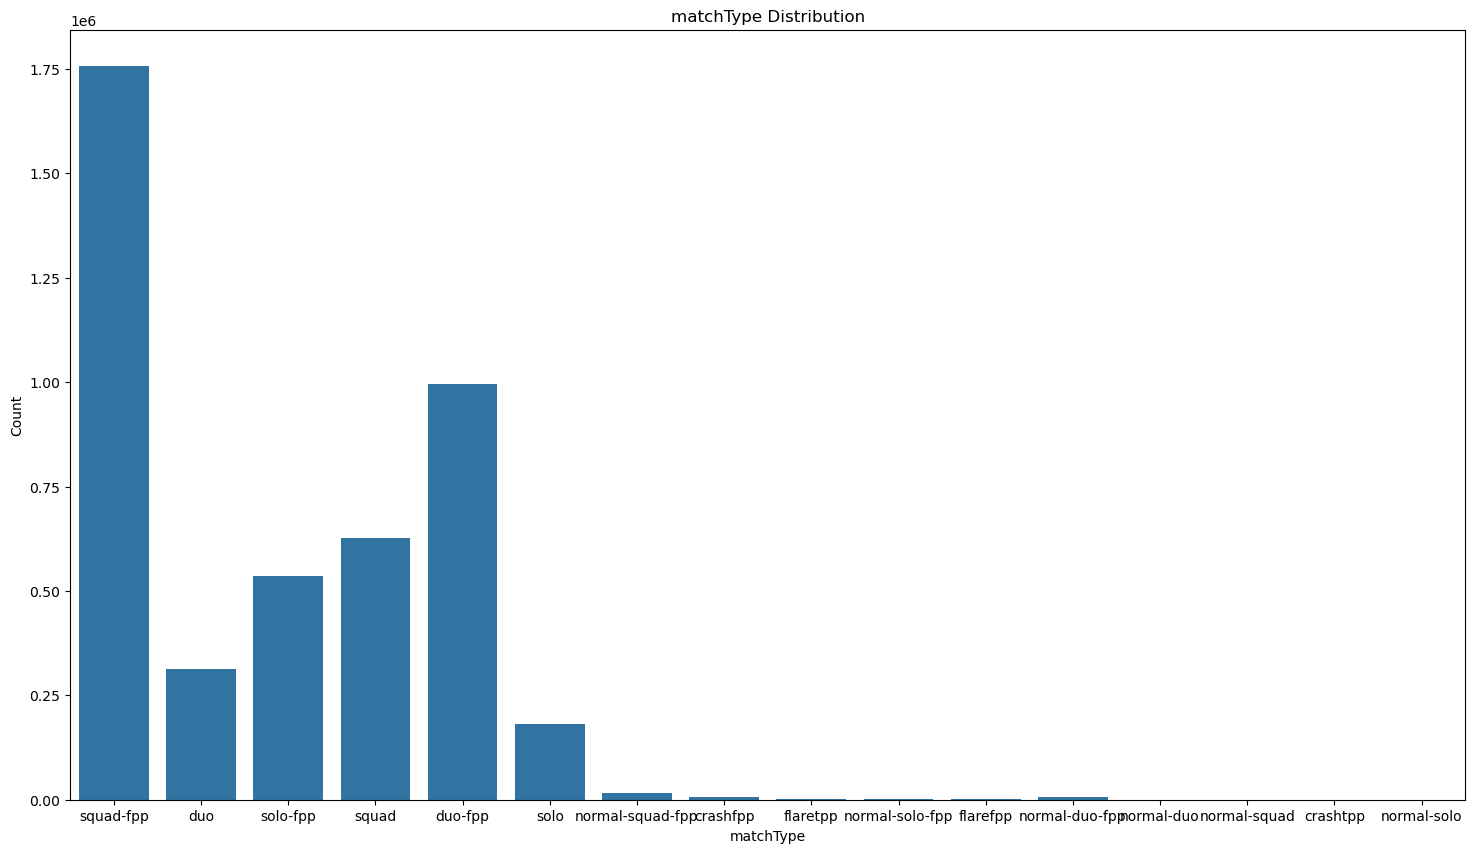

matchType
squad-fpp           0.394918
duo-fpp             0.224128
squad               0.140888
solo-fpp            0.120703
duo                 0.070518
solo                0.040914
normal-squad-fpp    0.003862
crashfpp            0.001414
normal-duo-fpp      0.001234
flaretpp            0.000563
normal-solo-fpp     0.000378
flarefpp            0.000161
normal-squad        0.000116
crashtpp            0.000083
normal-solo         0.000073
normal-duo          0.000045
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(18,10))
sns.countplot(x='matchType', data=pubg)
plt.title("matchType Distribution")
plt.xlabel("matchType")
plt.ylabel("Count")
plt.show()
print(pubg['matchType'].value_counts(normalize=True))

#### Insight
- This Indicates that Squad-Fpp match has Played more than other Games.

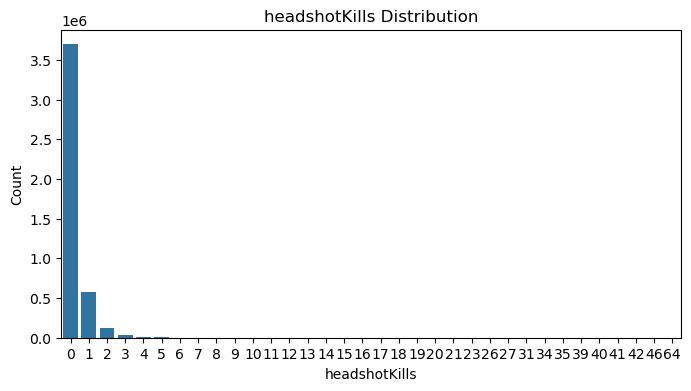

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(x='headshotKills', data=pubg)
plt.title("headshotKills Distribution")
plt.xlabel("headshotKills")
plt.ylabel("Count")
plt.show()

#### Insight
- The headshot distribution indicates that only a small number of kills occurred through headshots.
- When players attempted a headshot, it typically resulted in either a single kill or a missed shot.

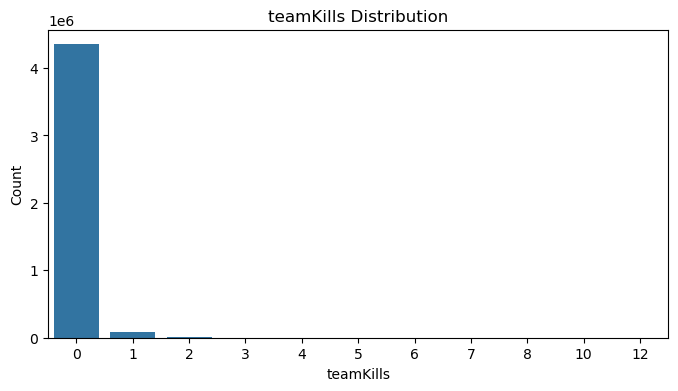

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(x='teamKills', data=pubg)
plt.title("teamKills Distribution")
plt.xlabel("teamKills")
plt.ylabel("Count")
plt.show()

#### Insight
- A very small number of players have 1 or more team kills, indicating that team killing is a rare event in the dataset.

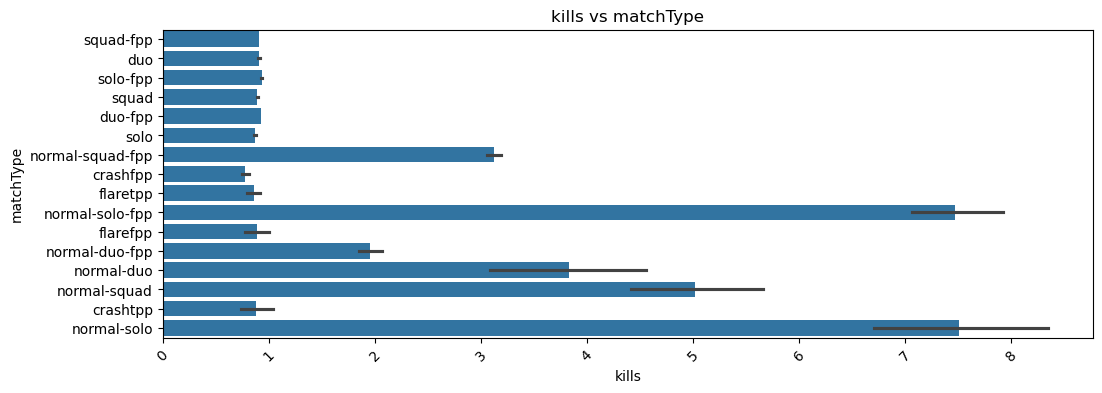

In [14]:
plt.figure(figsize=(12,4))
sns.barplot(x='kills', y='matchType', data=pubg)
plt.title("kills vs matchType")
plt.xticks(rotation=45)
plt.show()

#### Insight
- Normal modes (normal-solo, normal-squad, normal-duo) show the highest kill counts
These modes consistently have higher average kills, especially normal-solo and normal-squad, indicating players tend to engage more aggressively in these match types.
- Event/rare modes (flarefpp, crashtpp, flaretpp) show very low kill counts These modes may involve fewer players, special conditions, or unique rules leading to limited combat.
- Regular non-event TPP modes (solo, duo, squad) fall in the mid-range They show moderate kill numbers, not as high as the normal modes but more than rare modes.
- Normal-solo stands out with the highest kill potential Solo matches naturally require players to fight independently, resulting in more engagements per player.

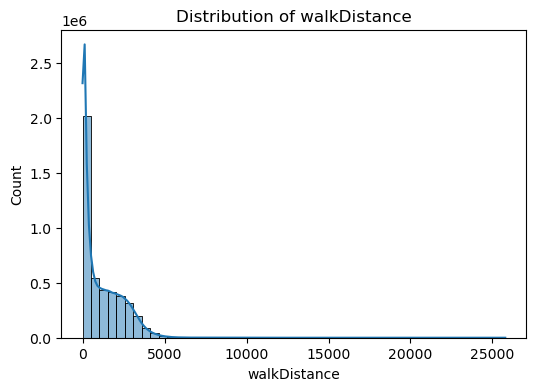

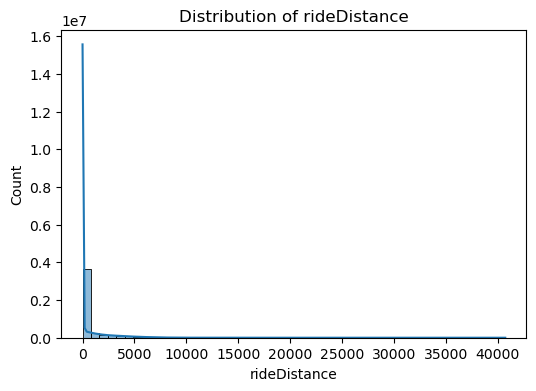

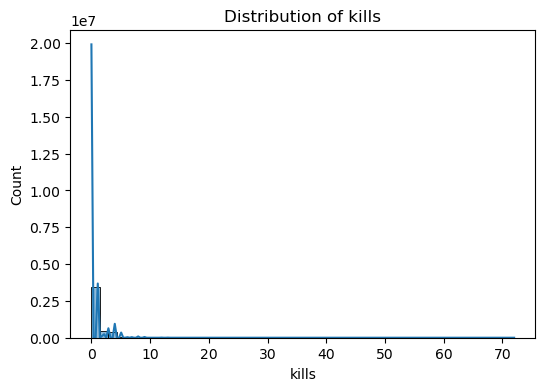

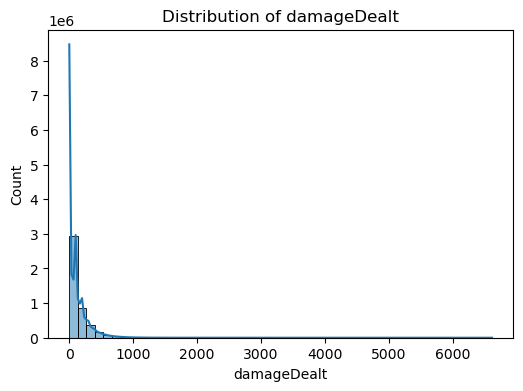

In [16]:
num_cols = ['walkDistance', 'rideDistance', 'kills', 'damageDealt']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(pubg[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

### Distribution Analysis of Numerical Features

• **WalkDistance**  
The distribution of walkDistance is highly right-skewed, with the majority of
players covering shorter distances during a match, while a smaller proportion
travels significantly longer distances. The long tail indicates high-mobility
players, which is expected in PUBG gameplay and represents valid in-game
behavior rather than anomalies.

• **RideDistance**  
The rideDistance feature shows extreme right skewness with a large number of
zero or near-zero values. This suggests that many players do not use vehicles
in every match, while a smaller group relies heavily on vehicles depending on
map size and strategy. These extreme values are gameplay-driven and meaningful.

• **Kills**  
The kills distribution is heavily concentrated at lower values, with most
players achieving fewer than 3 kills per match. High kill counts are rare,
indicating that aggressive gameplay is less common and reinforcing the
importance of survival and positioning over pure combat.

• **DamageDealt**  
The damageDealt feature exhibits a long-tailed distribution, where most players
deal relatively low to moderate damage, while a small fraction contributes very
high damage values. This highlights the presence of high-impact players and
confirms damageDealt as a strong predictor of match outcome.


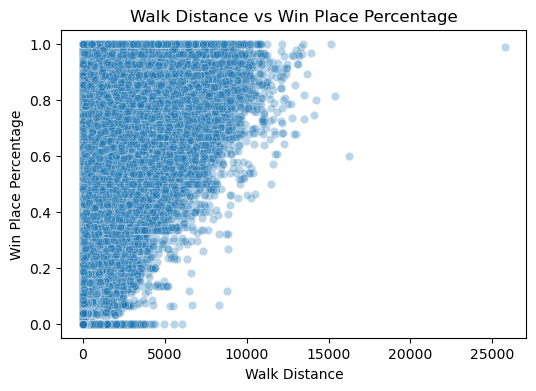

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=pubg['walkDistance'],
    y=pubg['winPlacePerc'],
    alpha=0.3
)
plt.title("Walk Distance vs Win Place Percentage")
plt.xlabel("Walk Distance")
plt.ylabel("Win Place Percentage")
plt.show()

#### Insight
- The scatter plot indicates a clear positive relationship between walkDistance
and winPlacePerc. Players who move more during a match tend to achieve better
final placements, highlighting mobility as a key factor influencing match
outcomes in PUBG.


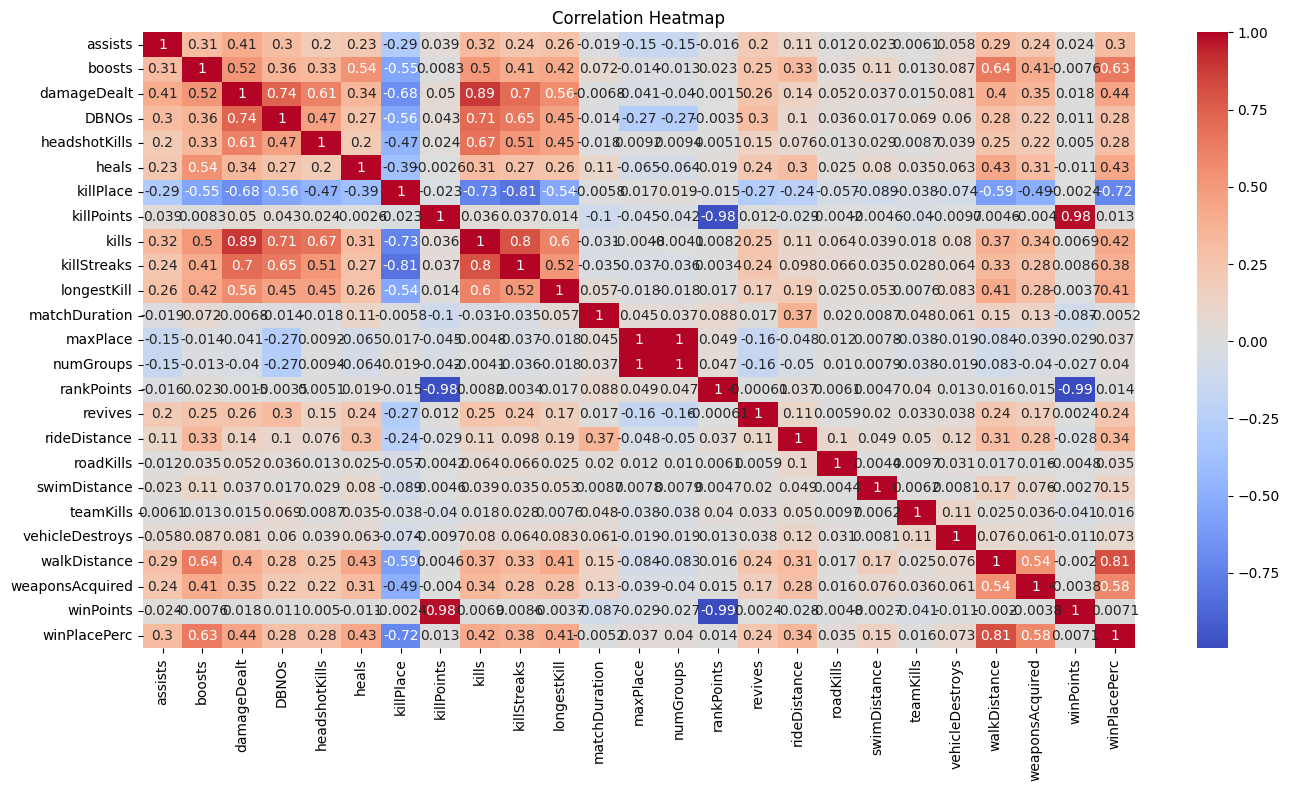

In [10]:
plt.figure(figsize=(16,8))
sns.heatmap(pubg.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Key Insights from Correlation Analysis

- Movement-related features such as walkDistance (0.81), rideDistance (0.59), and swimDistance (0.44) show the strongest positive correlation with winPlacePerc.
This indicates that mobility plays a crucial role in increasing a player’s survival and final ranking.

- Boosts (0.63) and heals (0.51) show a strong positive correlation with winPlacePerc, indicating that sustained survival through healing and resource management plays a critical role in achieving higher final placement. This highlights that longevity in the game contributes more consistently to winning than short-term aggressive actions.

- killPlace exhibits a strong negative correlation (–0.72) with winPlacePerc, confirming that higher combat effectiveness improves placement; however, when compared with mobility and survival metrics, combat alone is insufficient. This suggests that optimal performance results from a balance between strategic movement, survival, and selective combat rather than purely aggressive gameplay.

- Highly correlated feature groups such as kills & killPoints (0.93) and winPoints & winPlacePerc (0.71) indicate the presence of multicollinearity within the dataset. Rather than eliminating these features outright, they were retained to allow tree-based models to internally manage correlation while preserving potentially meaningful information related to player performance.

These indicate multicollinearity within the dataset.

- Combat-related features such as DBNOs and headshotKills show only moderate correlation with winPlacePerc, indicating that while combat skill contributes to success, it is not the dominant factor. This reinforces the conclusion that strategic movement, positioning, and survival duration are more influential determinants of final placement than raw combat intensity alone.

- matchDuration exhibits minimal correlation with winPlacePerc, suggesting that the outcome is driven more by player behavior within the match rather than the overall length of gameplay. This indicates that performance quality, rather than match duration, is the key determinant of ranking outcomes.

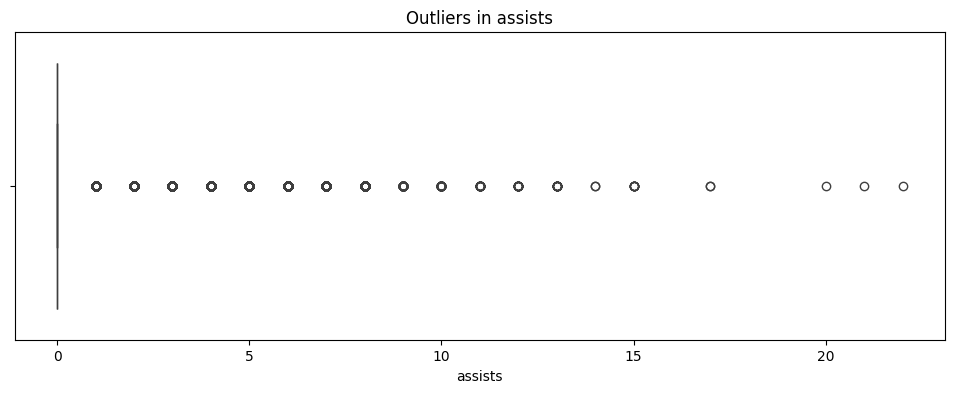

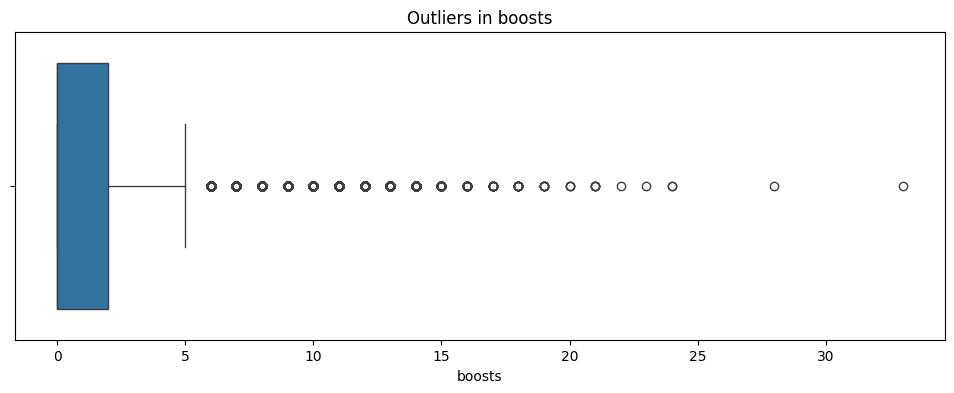

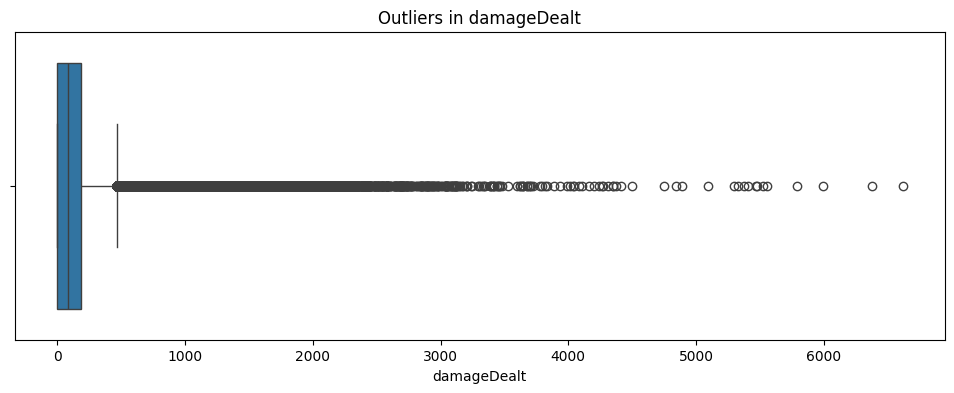

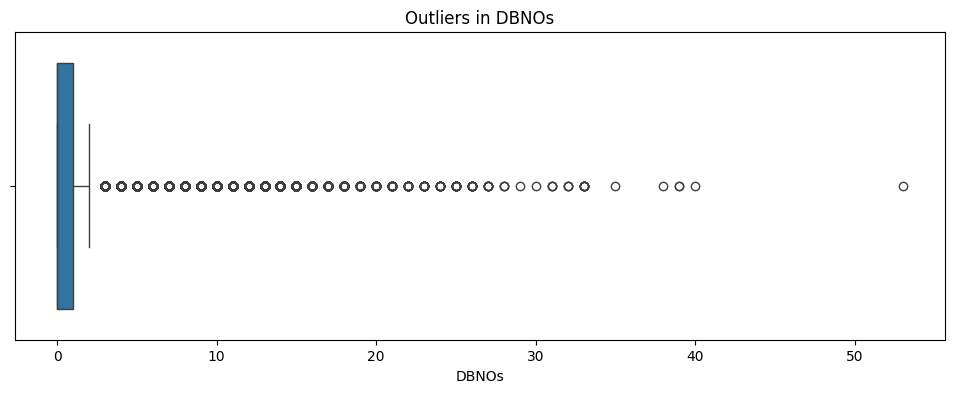

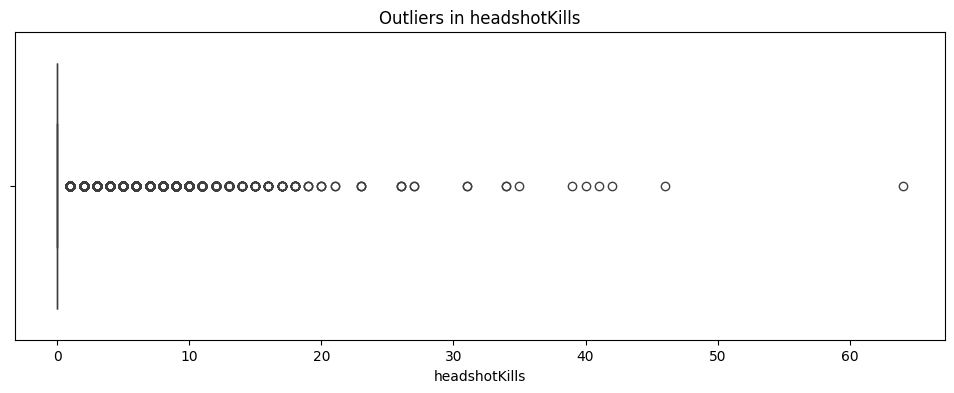

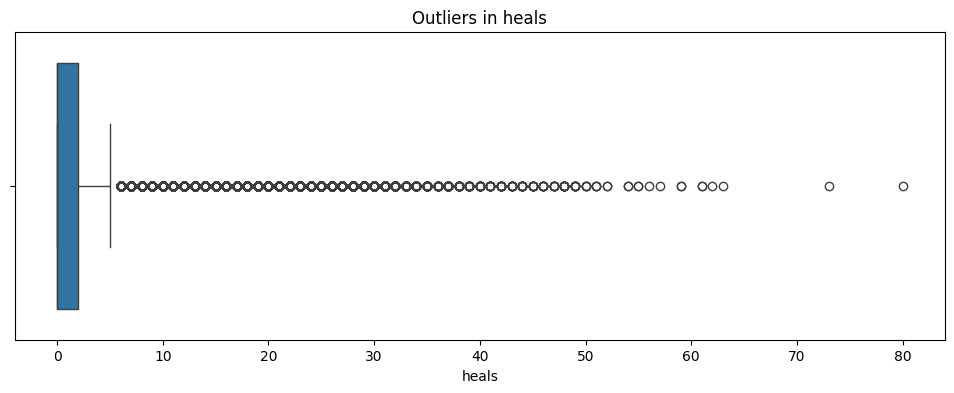

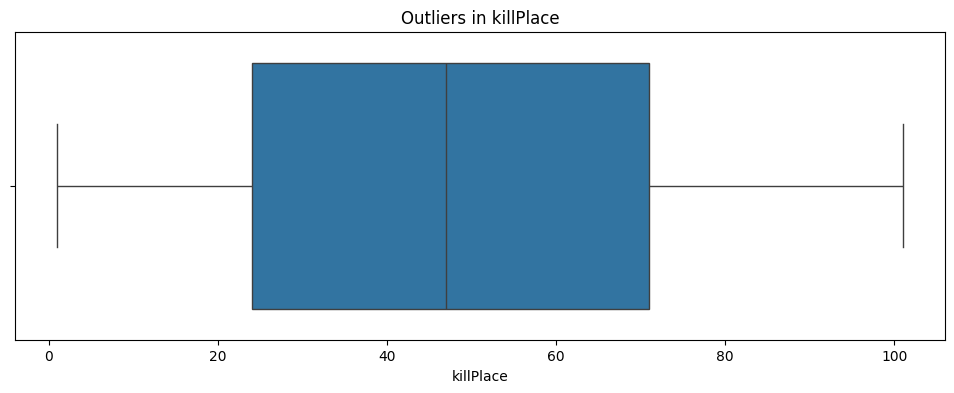

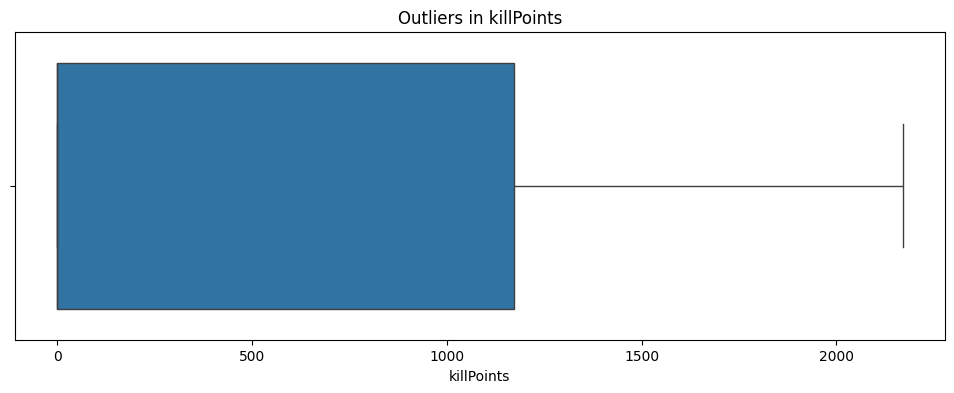

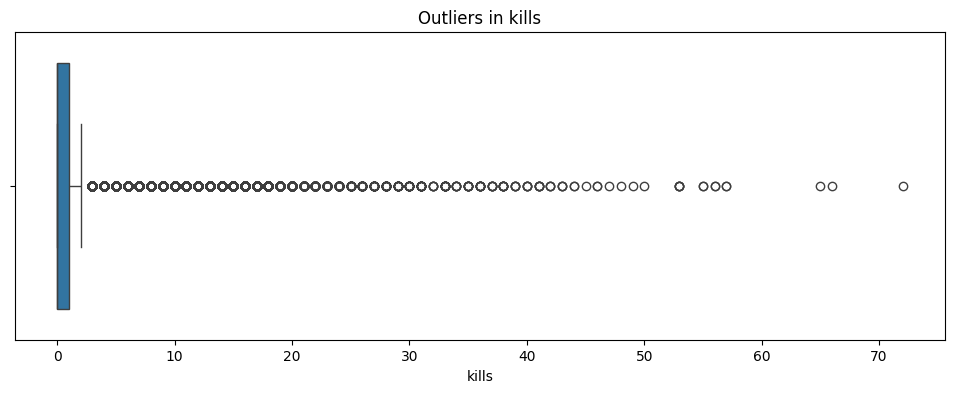

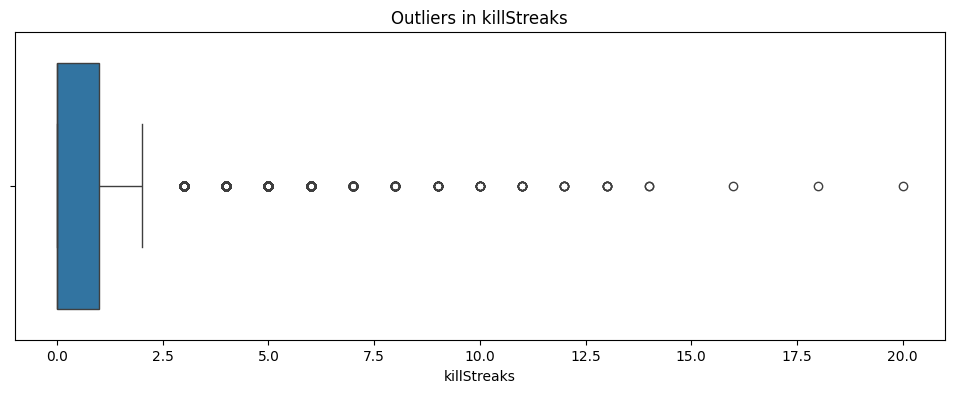

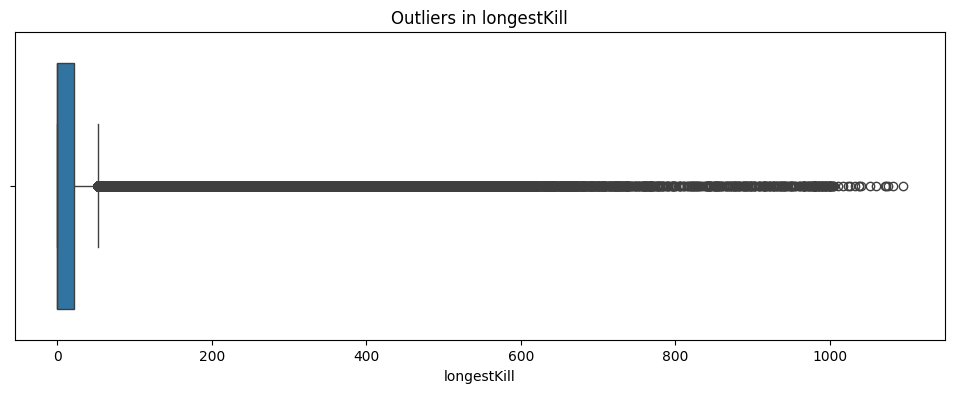

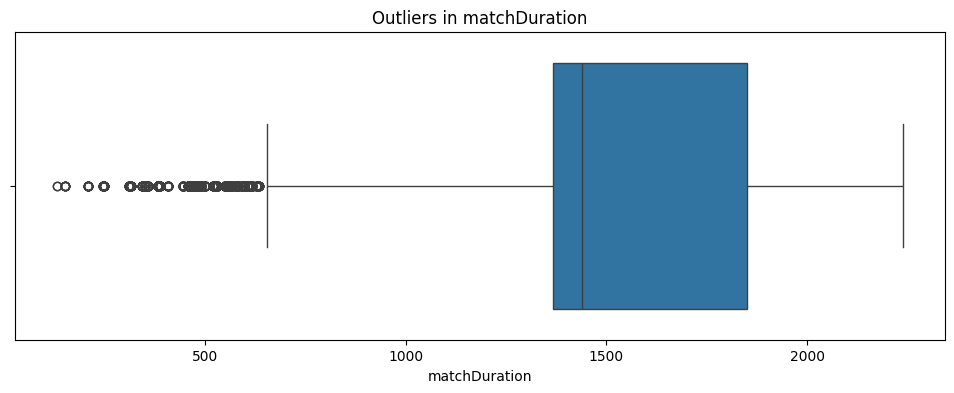

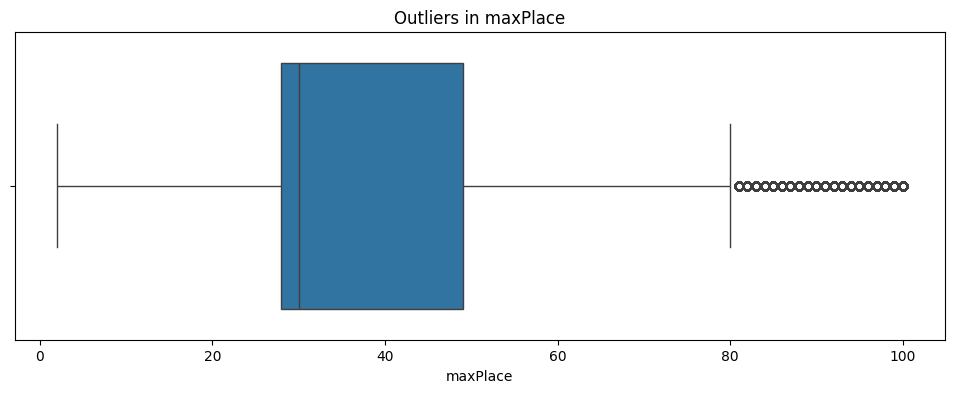

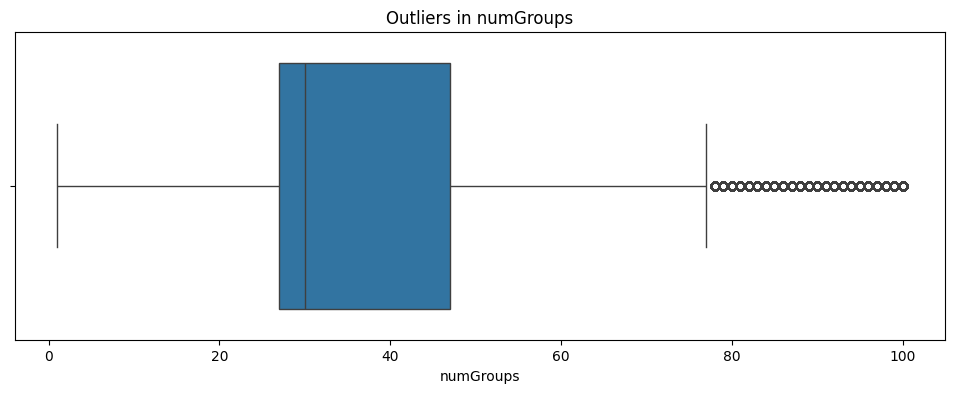

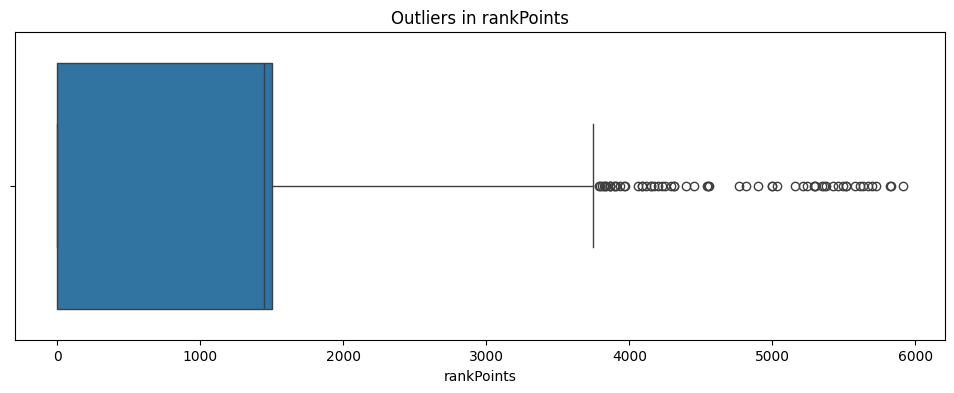

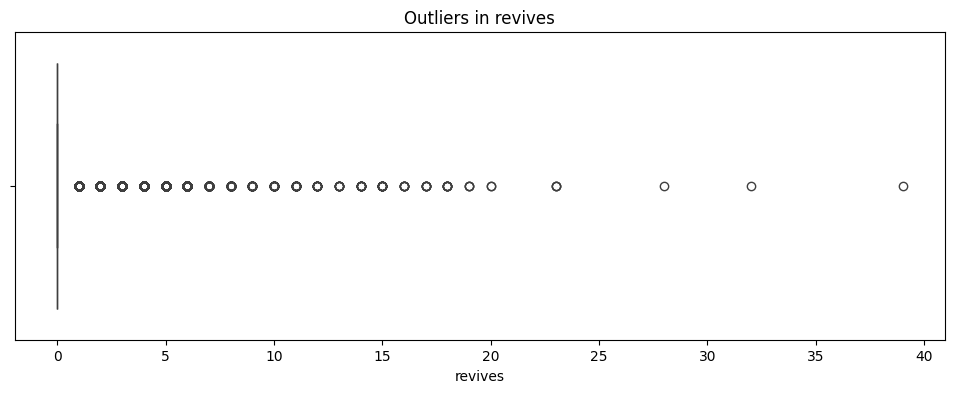

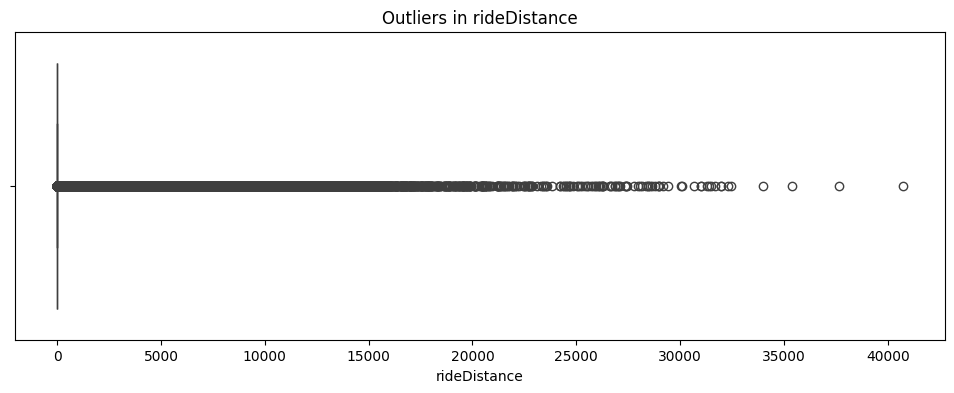

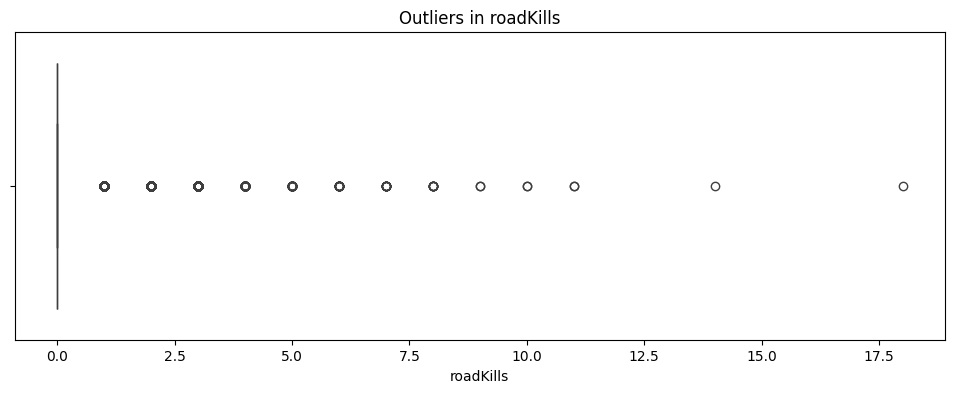

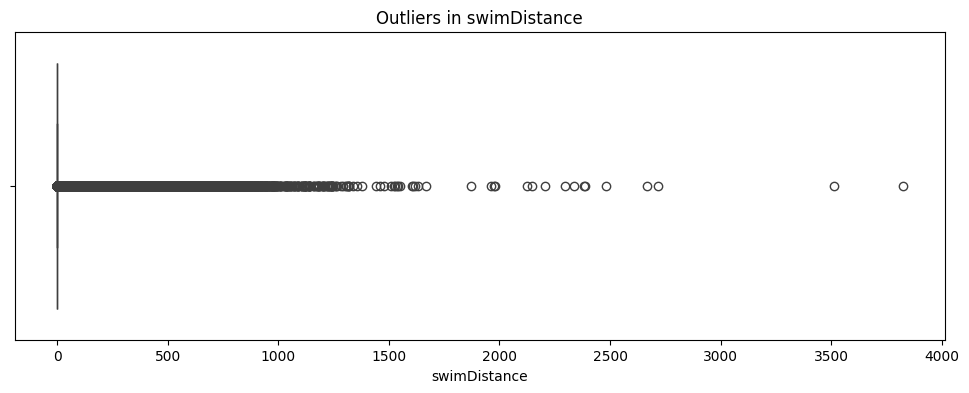

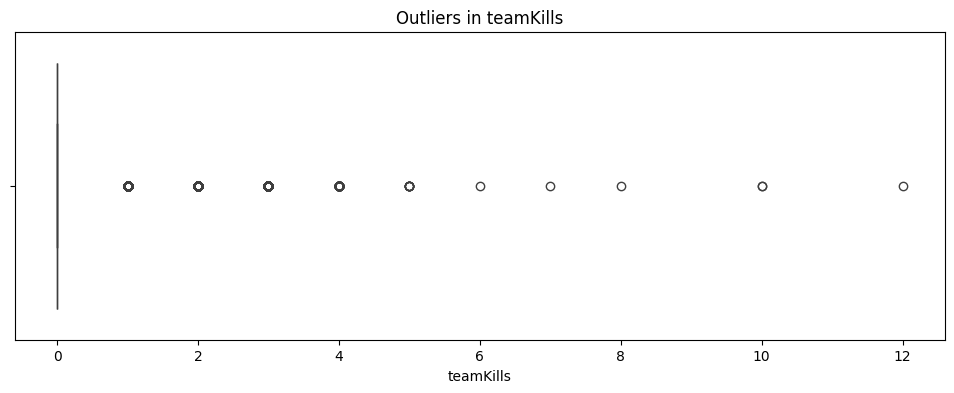

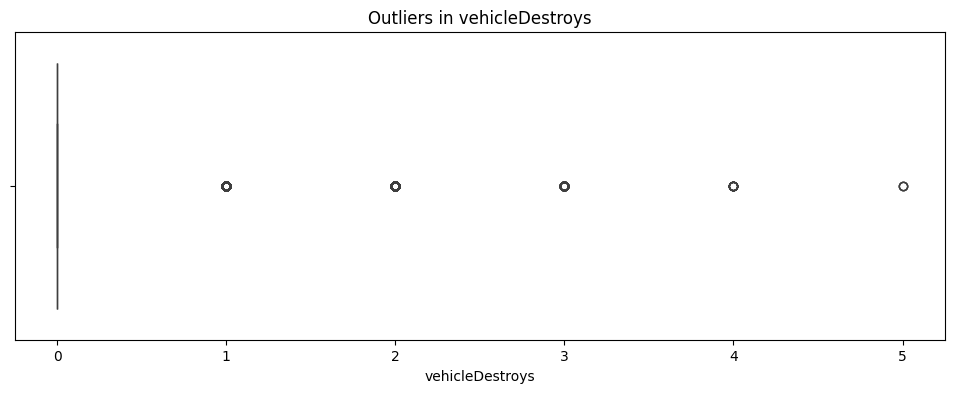

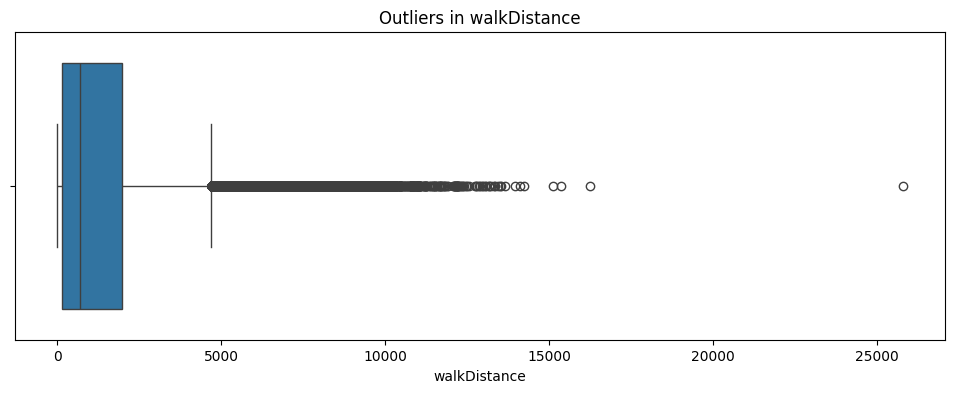

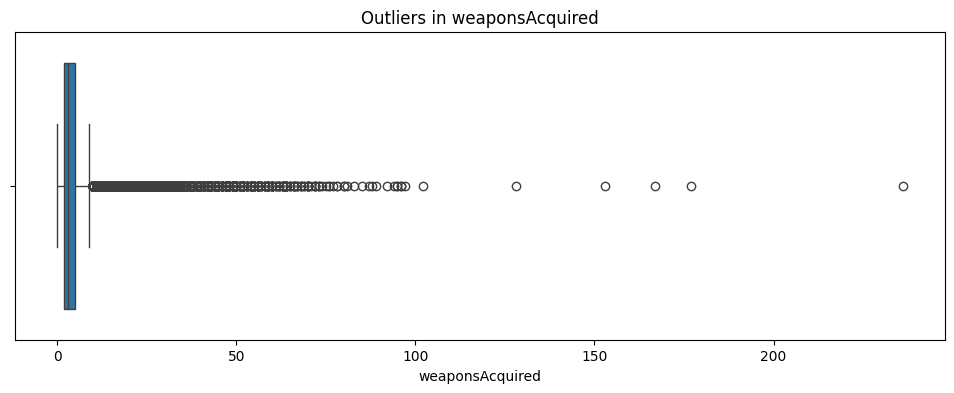

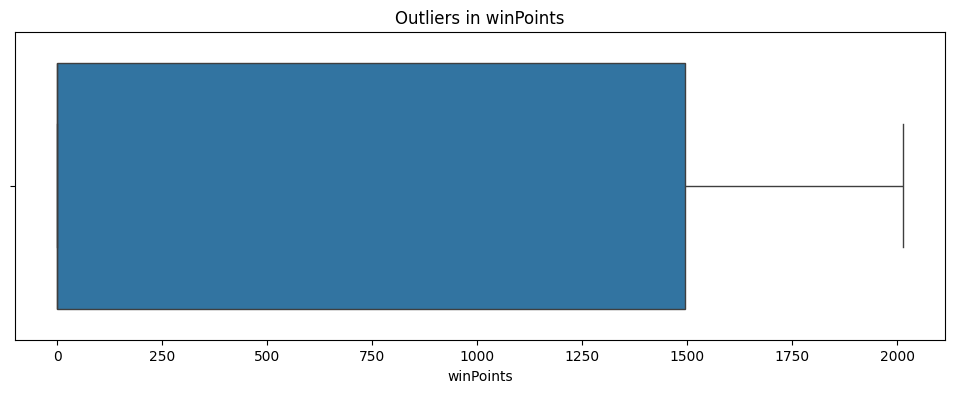

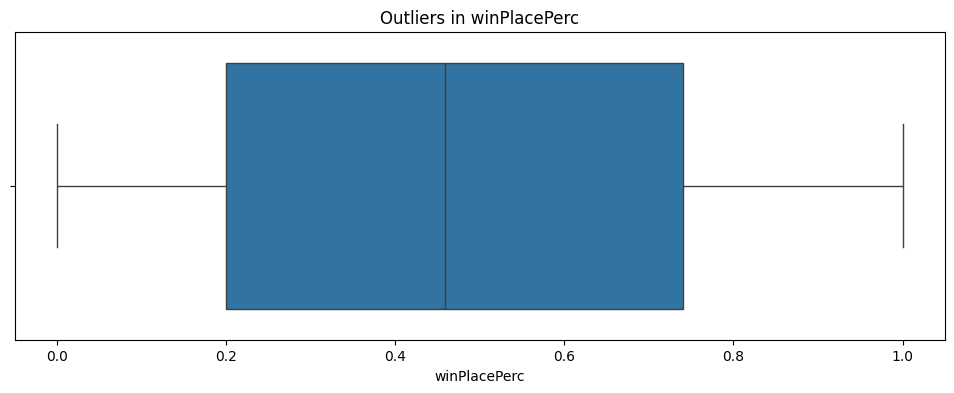

In [12]:
num_cols = pubg.drop("winPlacePerc", axis=1)
num_cols = pubg.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=pubg[col])
    plt.title(f"Outliers in {col}")
    plt.show()

- Several features show outliers, they represent valid game situations. These values are important for modeling real PUBG behavior, so no outlier removal is applied.
- Therefore, these outliers are intentionally retained, as removing them would distort the true distribution of on-field behavior and reduce the model’s ability to generalize to real gameplay scenarios.

In [9]:
pubg["matchType"].unique()

array(['squad-fpp', 'duo', 'solo-fpp', 'squad', 'duo-fpp', 'solo',
       'normal-squad-fpp', 'crashfpp', 'flaretpp', 'normal-solo-fpp',
       'flarefpp', 'normal-duo-fpp', 'normal-duo', 'normal-squad',
       'crashtpp', 'normal-solo'], dtype=object)

#### 4. Scaling and Feature Engineering

##### Encoding
- Categorical features were encoded into numerical values for model compatibility

In [18]:
pubg = pd.get_dummies(pubg, columns=["matchType"], drop_first=True)
pubg.shape

(4446965, 40)

##### Separate Input and Output

In [19]:
x=pubg.drop("winPlacePerc", axis=1)
y=pubg["winPlacePerc"]

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train", y_train.shape)
print("y_test",y_test.shape)

x_train (3112875, 39)
x_test (1334090, 39)
y_train (3112875,)
y_test (1334090,)


In [21]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### 5. Model Development
Testing with Multiple Models for Better Prediction

#### Linear Regression

In [22]:
lr=LinearRegression()
lr

LinearRegression()

In [23]:
lr.fit(x_train,y_train)

LinearRegression()

In [38]:
y_train_pred_lr = lr.predict(x_train)
y_test_pred_lr  = lr.predict(x_test)

#### Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1.SAMPLE FROM TRAINING DATA ONLY

sample_frac = 0.01   # 1% sample
n_samples = int(sample_frac * x_train.shape[0])

np.random.seed(42)
sample_idx = np.random.choice(
    x_train.shape[0],
    size=n_samples,
    replace=False
)

X_sample = x_train[sample_idx]
y_sample = y_train.iloc[sample_idx]

# 2.RANDOM FOREST + GRIDSEARCH (ON SAMPLE)
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_sample, y_sample)

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

# 3.TRAIN FINAL RANDOM FOREST ON FULL TRAIN DATA

best_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(x_train, y_train)

# 4.PREDICTIONS

y_train_pred_rf = best_rf.predict(x_train)
y_test_pred_rf  = best_rf.predict(x_test)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


#### XGBOOST

In [58]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1.SAMPLE FROM TRAINING DATA ONLY

sample_frac = 0.02   
n_samples = int(sample_frac * x_train.shape[0])

np.random.seed(42)
sample_idx = np.random.choice(
    x_train.shape[0],
    size=n_samples,
    replace=False
)

X_sample = x_train[sample_idx]
y_sample = y_train.iloc[sample_idx]

# 2.XGBOOST + RANDOMIZEDSEARCHCV (ON SAMPLE)

xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',      
    n_jobs=2,                
    random_state=42
)
param_dist = {
    'n_estimators': [150, 200, 300],
    'max_depth': [5, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}


xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,      
    verbose=2
)

xgb_search.fit(X_sample, y_sample)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

# 3.TRAIN FINAL XGBOOST ON FULL TRAIN DATA

best_xgb = XGBRegressor(
    **xgb_search.best_params_,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=2,
    random_state=42
)

best_xgb.fit(x_train, y_train)

# 4.PREDICTIONS

y_train_pred_xgb = best_xgb.predict(x_train)
y_test_pred_xgb  = best_xgb.predict(x_test)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time=   1.6s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.8; total time=   0.9s
[CV] END colsampl

#### LightGBM

In [59]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1.SAMPLE FROM TRAINING DATA ONLY
sample_frac = 0.03
n_samples = int(sample_frac * x_train.shape[0])

np.random.seed(42)
sample_idx = np.random.choice(
    x_train.shape[0],
    size=n_samples,
    replace=False
)

X_sample = x_train[sample_idx]
y_sample = y_train.iloc[sample_idx]

# 2.LIGHTGBM + RANDOMIZEDSEARCHCV (ON SAMPLE)

lgbm = LGBMRegressor(random_state=42)

param_dist = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 15],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=15,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_sample, y_sample)

print("Best LightGBM Parameters:")
print(random_search.best_params_)

# 3.TRAIN FINAL LIGHTGBM ON FULL TRAIN DATA

best_lgbm = LGBMRegressor(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_lgbm.fit(x_train, y_train)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2806
[LightGBM] [Info] Number of data points in the train set: 93386, number of used features: 34
[LightGBM] [Info] Start training from score 0.473030
Best LightGBM Parameters:
{'subsample': 0.9, 'num_leaves': 70, 'n_estimators': 700, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.305000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2859
[LightGBM] [Info] Number of data points in the train set: 3112875, number of used features: 39
[LightGBM] [Info] Start train

LGBMRegressor(colsample_bytree=0.9, learning_rate=0.03, n_estimators=700,
              n_jobs=-1, num_leaves=70, random_state=42, subsample=0.9)

In [60]:
# 4. PREDICTIONS
y_train_pred_lgbm = best_lgbm.predict(x_train)
y_test_pred_lgbm  = best_lgbm.predict(x_test)

C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


- The PUBG dataset contains over four million records, making full-scale model training and hyperparameter tuning computationally expensive and memory-intensive, especially for tree-based ensemble models. To address these challenges, sampling was used strategically during model training and tuning.

- Sampling was applied to reduce memory usage, training time, and computational overhead while still preserving the underlying data distribution. A representative subset of the training data allows models to learn optimal hyperparameters efficiently without compromising overall model performance.

- For models such as Random Forest, sampling was necessary due to their high memory requirements and the cost of training multiple trees during hyperparameter tuning. Although XGBoost and LightGBM are optimized for large-scale datasets, sampling was still employed in certain cases to ensure stable execution within available system resources.

- Importantly, sampling was performed only on the training data to prevent data leakage. After identifying optimal hyperparameters using the sampled data, all models were retrained on the full training dataset and evaluated on a held-out test set. This approach ensured reliable performance evaluation and fair comparison across models.

- Overall, sampling enabled efficient model development while maintaining accuracy, robustness, and methodological correctness.

In [61]:
def evaluate_model(name, y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Model": name,

        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),

        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),

        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }


In [62]:
results_list = []

results_list.append(
    evaluate_model(
        "Linear Regression",
        y_train, y_train_pred_lr,
        y_test, y_test_pred_lr
    )
)
results_list.append(
    evaluate_model(
        "Random Forest",
        y_train, y_train_pred_rf,
        y_test, y_test_pred_rf
    )
)
results_list.append(
    evaluate_model(
        "XGBoost",
        y_train, y_train_pred_xgb,
        y_test, y_test_pred_xgb
    )
)

results_list.append(
    evaluate_model(
        "LightGBM",
        y_train, y_train_pred_lgbm,
        y_test, y_test_pred_lgbm
    )
)

results_df = pd.DataFrame(results_list)
results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.839754,0.839549,0.089899,0.089902,0.123081,0.123079
1,Random Forest,0.955697,0.929804,0.045888,0.057703,0.064716,0.081408
2,XGBoost,0.933004,0.931765,0.057124,0.057393,0.079583,0.080263
3,LightGBM,0.934411,0.933218,0.056558,0.056810,0.078743,0.079403


#### Why Big Data Technologies Were Not Used

1. Although the dataset contains 4.4 million rows, it still fits within the capacity of modern local systems and can be efficiently processed using optimized libraries such as Pandas and LightGBM.
2. In this project, the dataset was large but manageable, and LightGBM's histogram-based algorithm handled it efficiently without requiring distributed processing. Therefore, using Big Data frameworks would have introduced unnecessary complexity without providing meaningful performance benefits.

### 6.Conclusion

- This project focused on predicting winPlacePerc using the PUBG dataset, which is large in scale and complex in nature. Due to the size of the dataset, special attention was given to preprocessing, memory management, and model selection to ensure both computational feasibility and reliable performance evaluation.

- Linear Regression was implemented as a baseline model to understand the general relationship between features and the target variable. While it produced stable results, its relatively lower performance indicates that linear assumptions are insufficient to capture the complex, non-linear patterns present in the data.

- Random Forest demonstrated strong training performance; however, a noticeable difference between training and testing metrics indicates mild overfitting. Additionally, Random Forest required sampling during hyperparameter tuning due to its high memory and computational requirements on large datasets. This limitation reduces its suitability as a final model despite good accuracy.

- XGBoost and LightGBM, both gradient boosting models, showed significantly better generalization performance. These models effectively handled non-linear relationships and large-scale data. Among all evaluated models, LightGBM achieved the highest test R² score and the lowest MAE and RMSE, indicating superior predictive accuracy and robustness on unseen data.

- Sampling was applied selectively during hyperparameter tuning to manage system memory constraints while preserving data distribution. Importantly, all final models were trained on the full training dataset and evaluated on the same held-out test set, ensuring a fair and unbiased comparison.

- Based on empirical evaluation results and generalization performance, LightGBM was selected as the final model. Its ability to efficiently handle large datasets while delivering the best test performance makes it the most suitable model for this problem.